### Name: Riya Shyam Huddar
### Roll No.: MDS202431
### Quantum Computing - Portfolio Optimization Assignment 3

In [12]:
# Imports
import os
import pandas as pd
import numpy as np
import cvxpy as cp
from scipy import sparse
import clarabel
import matplotlib.pyplot as plt
import time

### Loading and Pre-processing

### Data Loading

Historical price data is loaded from individual CSV files, with each file
representing a single asset. The asset symbol is inferred from the filename.
Completely empty columns are removed, and all assets are combined into a
single DataFrame for downstream feature engineering and modeling.


In [13]:
data_dir = r"D:\CMI\IP\archive"

dfs = []

for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        symbol = file.replace(".csv", "")
        file_path = os.path.join(data_dir, file)
        
        df = pd.read_csv(file_path)

        # Drop completely empty columns 
        df = df.dropna(axis=1, how="all")

        df["Symbol"] = symbol
        dfs.append(df)

raw_data = pd.concat(dfs, ignore_index=True)


In [14]:
raw_data.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company Name,Industry,ISIN Code
0,2007-11-27,ADANIPORTS,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366.0,2.687719e+15,NaN,9859619.0,0.3612,NaN,NaN,NaN
1,2007-11-28,ADANIPORTS,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338.0,4.312765e+14,NaN,1453278.0,0.3172,NaN,NaN,NaN
2,2007-11-29,ADANIPORTS,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121.0,4.550658e+14,NaN,1069678.0,0.2088,NaN,NaN,NaN
3,2007-11-30,ADANIPORTS,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762.0,4.283257e+14,NaN,1260913.0,0.2735,NaN,NaN,NaN
4,2007-12-03,ADANIPORTS,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470.0,2.875200e+14,NaN,816123.0,0.2741,NaN,NaN,NaN


### Data Cleaning and Asset Universe Selection

Dates are parsed and invalid entries removed before sorting the data by
asset and time. Closing prices are reshaped into a price matrix with
dates as rows and assets as columns.

Missing data is analyzed to understand coverage differences across assets.
Two universe constructions are considered: 
- a full universe requiring
complete data across all assets, and 
- an extended-history universe that
removes assets with excessive missing observations to retain a longer time
span.

In [16]:
raw_data["Date"] = pd.to_datetime(raw_data["Date"], errors="coerce")
raw_data = raw_data.dropna(subset=["Date"])
raw_data["Date"].isnull().sum()

0

In [17]:
raw_data = raw_data.sort_values(["Symbol", "Date"])

In [19]:
price_data = raw_data[["Date", "Symbol", "Close"]].copy()
price_data.head()

,Date,Symbol,Close
0,2007-11-27,ADANIPORTS,962.90
1,2007-11-28,ADANIPORTS,893.90
2,2007-11-29,ADANIPORTS,884.20
3,2007-11-30,ADANIPORTS,921.55
4,2007-12-03,ADANIPORTS,969.30


In [24]:
price_data = (
    price_data
    .groupby(["Date", "Symbol"], as_index=False)
    .last()
)

price_data.duplicated(subset=["Date", "Symbol"]).sum()

0

In [26]:
price_matrix = price_data.pivot(
    index="Date",
    columns="Symbol",
    values="Close"
)
price_matrix.head()

Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,381.65,26.70,NaN,NaN,50.75,NaN,399.25,756.90,1457.35,...,216.75,152.45,NaN,NaN,155.70,NaN,NaN,116.35,2724.20,1179.95
2000-01-04,NaN,385.55,26.85,NaN,NaN,48.10,NaN,370.50,754.55,1465.25,...,208.20,150.80,NaN,NaN,147.40,NaN,NaN,114.70,2942.15,1260.65
2000-01-05,NaN,383.00,26.30,NaN,NaN,44.60,NaN,359.95,735.30,1435.05,...,213.25,156.55,NaN,NaN,138.40,NaN,NaN,114.00,2990.10,1176.55
2000-01-06,NaN,377.50,25.95,NaN,NaN,45.25,NaN,380.30,785.65,1355.85,...,222.10,168.25,NaN,NaN,149.50,NaN,NaN,119.30,2932.25,1115.45
2000-01-07,NaN,385.70,24.80,NaN,NaN,42.90,NaN,379.85,848.50,1247.55,...,239.90,171.95,NaN,NaN,146.35,NaN,NaN,116.50,2697.70,1026.25


In [28]:
rows_before = len(price_matrix)
rows_after = len(price_matrix.dropna())

print(f"Original number of days: {rows_before}")
print(f"Days remaining if we drop all NaNs: {rows_after}")
print(f"Percentage of data lost: {100 * (1 - rows_after/rows_before):.2f}%")

Original number of days: 5306
Days remaining if we drop all NaNs: 2598
Percentage of data lost: 51.04%


In [30]:
# stocks with maximum NaN's 
price_matrix.isnull().sum().sort_values(ascending=False).head(10)

Symbol
COALINDIA     2708
NESTLEIND     2500
BAJAJFINSV    2105
BAJAJ-AUTO    2104
ADANIPORTS    1984
POWERGRID     1947
TECHM         1671
JSWSTEEL      1312
NTPC          1218
TCS           1167
dtype: int64

In [32]:
# APPROACH 1: Full Universe 
# We keep every single symbol, which forces the timeline to start 
# only when the "youngest" stock was listed.
price_matrix_full = price_matrix.dropna()

# APPROACH 2: Extended History
# We identify the stocks that are "killing" our history (missing > 1100 days).
# By removing just these few, we "unlock" many more years of data for the rest.
nan_counts = price_matrix.isnull().sum()
killers = nan_counts[nan_counts > 1100].index
price_matrix_extended = price_matrix.drop(columns=killers).dropna()

# --- DIAGNOSTICS ---
print("--- APPROACH 1: FULL UNIVERSE ---")
print(f"Stocks: {price_matrix_full.shape[1]}")
print(f"Days: {len(price_matrix_full)}")
print(f"Timeline: {price_matrix_full.index.min().date()} to {price_matrix_full.index.max().date()}")

print("\n--- APPROACH 2: EXTENDED HISTORY ---")
print(f"Stocks: {price_matrix_extended.shape[1]}")
print(f"Days: {len(price_matrix_extended)}")
print(f"Timeline: {price_matrix_extended.index.min().date()} to {price_matrix_extended.index.max().date()}")

--- APPROACH 1: FULL UNIVERSE ---
Stocks: 50
Days: 2598
Timeline: 2010-11-04 to 2021-04-30

--- APPROACH 2: EXTENDED HISTORY ---
Stocks: 38
Days: 4286
Timeline: 2004-01-23 to 2021-04-30


In [34]:
# --- STEP 1: Compute daily returns ---

returns_full = price_matrix_full.pct_change().dropna()
returns_extended = price_matrix_extended.pct_change().dropna()

print("Full universe returns shape:", returns_full.shape)
print("Extended universe returns shape:", returns_extended.shape)


Full universe returns shape: (2597, 50)
Extended universe returns shape: (4285, 38)


 ----
 -----

### 1. ML-Based Return or Risk Estimation

### Feature Engineering: Lagged and Rolling Return Features

Predictive inputs are constructed using lagged return features (1, 5, 10,
and 15 days) and rolling statistics derived from past returns. Lagged
returns capture short-term persistence and reversal effects.

Rolling momentum features are computed as cumulative returns over
5, 10, and 20-day windows (rolling sums of past returns), capturing
short-horizon trend effects. Rolling volatility features are computed
as the 10-day and 20-day rolling standard deviation of past returns,
serving as proxies for recent risk conditions.

All rolling features are based on returns shifted by one period, ensuring
that only information available up to time $t-1$ is used and eliminating
look-ahead bias. Features are constructed separately for the full and
extended asset universes.

In [36]:
# --- STEP 2: Lagged return features ---

# Full universe
lag1_full  = returns_full.shift(1)
lag5_full  = returns_full.shift(5)
lag10_full = returns_full.shift(10)
lag15_full = returns_full.shift(15)

# Extended universe
lag1_ext  = returns_extended.shift(1)
lag5_ext  = returns_extended.shift(5)
lag10_ext = returns_extended.shift(10)
lag15_ext = returns_extended.shift(15)

print("Lagged features created (1,5,10,15)")


Lagged features created (1,5,10,15)


In [38]:
# --- STEP 3: Rolling features ---

# Full universe
vol10_full  = returns_full.shift(1).rolling(10).std()
vol20_full  = returns_full.shift(1).rolling(20).std()

# Extended universe
vol10_ext  = returns_extended.shift(1).rolling(10).std()
vol20_ext  = returns_extended.shift(1).rolling(20).std()

print("Expanded rolling features created")


Expanded rolling features created


In [40]:
mom5_full  = returns_full.shift(1).rolling(5).sum()
mom10_full = returns_full.shift(1).rolling(10).sum()
mom20_full = returns_full.shift(1).rolling(20).sum()

mom5_ext  = returns_extended.shift(1).rolling(5).sum()
mom10_ext = returns_extended.shift(1).rolling(10).sum()
mom20_ext = returns_extended.shift(1).rolling(20).sum()


### Prediction Target Definition

The supervised learning target is defined as the **15-day forward cumulative return**, denoted by $R_{t+1:t+15}$. This target aggregates asset returns over the next 15 trading days.

Formally,

$$
R_{t+1:t+15} = \sum_{i=1}^{15} r_{t+i}
$$

To prevent look-ahead bias, the cumulative returns are shifted backward by 15 periods so that features constructed using information available at time $t$ are used to predict returns over the future horizon $t+1$ to $t+15$.

The learning problem is therefore defined as

$$
\widehat{R}_{t+1:t+15} = f(X_t),
$$

where $X_t$ denotes the vector of lagged and rolling features constructed using information available up to time $t$.

In [42]:
# 15-day forward cumulative return
target_full = returns_full.rolling(15).sum().shift(-15)
target_ext  = returns_extended.rolling(15).sum().shift(-15)

print("15-day forward targets created")


15-day forward targets created


### ML Dataset Construction

Lagged and rolling features are combined into a feature matrix $X_t$ and
reshaped into long format, where each row corresponds to a
$(\text{Date}, \text{Symbol})$ pair. This stacked structure allows the model
to learn in a panel (cross-sectional time series) setting.

The target variable is the **15-day forward cumulative return**
$R_{t+1:t+15}$, defined as

$$
R_{t+1:t+15} = \sum_{i=1}^{15} r_{t+i}.
$$

Targets are aligned so that features constructed using information available
at time $t$ are used to predict returns over the future horizon
$t+1$ to $t+15$, thereby avoiding look-ahead bias.

After merging the feature matrix and target variable, missing observations
are removed once at the final stage. This procedure is applied separately
to the full and extended universes to construct supervised learning datasets
for model estimation.

In [44]:
# --- STEP 5A: Full universe ML dataset ---

# Combine all features
X_full = pd.concat(
    [
        lag1_full, lag5_full, lag10_full, lag15_full,
        vol10_full, vol20_full,
        mom5_full, mom10_full, mom20_full
    ],
    axis=1,
    keys=[
        "lag1","lag5","lag10","lag15",
        "vol10","vol20",
        "mom5","mom10","mom20"
    ]
)

# Stack to long format
X_full_long = (
    X_full
    .stack(future_stack=True)                       # stack symbols
    .reset_index()
)

# Rename columns properly
X_full_long.columns = [
    "Date", "Symbol",
    "lag1","lag5","lag10","lag15"
    ,"vol10","vol20",
    "mom5","mom10","mom20"
]

# Stack target
y_full_long = (
    target_full
    .stack(future_stack=True)
    .reset_index()
)

y_full_long.columns = ["Date", "Symbol", "target"]

# Merge features + target
ml_full = pd.merge(
    X_full_long,
    y_full_long,
    on=["Date", "Symbol"],
    how="inner"
)

# Drop NaNs once at the end
ml_full = ml_full.dropna().reset_index(drop=True)

print("Full universe ML data shape:", ml_full.shape)


Full universe ML data shape: (128100, 12)


In [46]:
# --- STEP 5B: Extended universe ML dataset ---

# Define feature column names once
feature_cols = [
    "lag1","lag5","lag10","lag15",
    "vol10","vol20",
    "mom5","mom10","mom20"
]

# Combine all features
X_ext = pd.concat(
    [
        lag1_ext, lag5_ext, lag10_ext, lag15_ext,
        vol10_ext, vol20_ext,
        mom5_ext, mom10_ext, mom20_ext
    ],
    axis=1,
    keys=feature_cols
)

# Stack to long format (future-safe)
X_ext_long = (
    X_ext
    .stack(future_stack=True)
    .reset_index()
)

# Assign correct column names
X_ext_long.columns = ["Date", "Symbol"] + feature_cols

# Stack target
y_ext_long = (
    target_ext
    .stack(future_stack=True)
    .reset_index()
)

y_ext_long.columns = ["Date", "Symbol", "target"]

# Merge features and target
ml_ext = pd.merge(
    X_ext_long,
    y_ext_long,
    on=["Date", "Symbol"],
    how="inner"
)

# Drop NaNs
ml_ext = ml_ext.dropna().reset_index(drop=True)

print("Extended universe ML data shape:", ml_ext.shape)


Extended universe ML data shape: (161500, 12)


### Train-Test Split

The dataset is divided using a fixed time-based cutoff. Observations before
the split date are used for training, while later observations are reserved
for out-of-sample testing.

Since the target is the 15-day forward cumulative return
$R_{t+1:t+15}$, a 15-day buffer is applied before the split date to ensure
that training targets do not incorporate returns from the test period.

This chronological split preserves time ordering and prevents look-ahead bias.

In [47]:
import pandas as pd

# --- STEP 6A: Train–test split (Full universe) ---

# Convert split_date to datetime
split_date = pd.to_datetime("2019-01-01")

# Forecast horizon (must match your target horizon)
horizon = 15

# Create buffer so training targets do not use test-period returns
train_cutoff = split_date - pd.Timedelta(days=horizon)

# Split dataset
train_full = ml_full[ml_full["Date"] < train_cutoff].copy()
test_full  = ml_full[ml_full["Date"] >= split_date].copy()

# Extract features and target
X_train_full = train_full.drop(columns=["Date", "Symbol", "target"])
y_train_full = train_full["target"]

X_test_full = test_full.drop(columns=["Date", "Symbol", "target"])
y_test_full = test_full["target"]

# Print diagnostics
print("Full universe")
print("Train date range:", train_full["Date"].min(), "to", train_full["Date"].max())
print("Test date range :", test_full["Date"].min(), "to", test_full["Date"].max())
print("Train shape:", X_train_full.shape)
print("Test shape :", X_test_full.shape)


Full universe
Train date range: 2010-12-06 00:00:00 to 2018-12-14 00:00:00
Test date range : 2019-01-01 00:00:00 to 2021-04-07 00:00:00
Train shape: (99500, 9)
Test shape : (28100, 9)


In [50]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# Overwrite training set 
X_train_full = pd.DataFrame(
    scaler.fit_transform(X_train_full),
    columns=X_train_full.columns,
    index=X_train_full.index
)

# Overwrite test set
X_test_full = pd.DataFrame(
    scaler.transform(X_test_full),
    columns=X_test_full.columns,
    index=X_test_full.index
)


In [52]:
# --- STEP 6B: Train–test split (Extended universe) ---

split_date = pd.to_datetime("2019-01-01")
horizon = 15
train_cutoff = split_date - pd.Timedelta(days=horizon)

train_ext = ml_ext[ml_ext["Date"] < train_cutoff].copy()
test_ext  = ml_ext[ml_ext["Date"] >= split_date].copy()

X_train_ext = train_ext.drop(columns=["Date", "Symbol", "target"])
y_train_ext = train_ext["target"]

X_test_ext = test_ext.drop(columns=["Date", "Symbol", "target"])
y_test_ext = test_ext["target"]

print("\nExtended universe")
print("Train date range:", train_ext["Date"].min(), "to", train_ext["Date"].max())
print("Test date range :", test_ext["Date"].min(), "to", test_ext["Date"].max())
print("Train shape:", X_train_ext.shape)
print("Test shape :", X_test_ext.shape)



Extended universe
Train date range: 2004-02-25 00:00:00 to 2018-12-14 00:00:00
Test date range : 2019-01-01 00:00:00 to 2021-04-07 00:00:00
Train shape: (139764, 9)
Test shape : (21356, 9)


In [54]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create a new scaler for extended universe
scaler_ext = StandardScaler()

# Overwrite training set (preserve structure)
X_train_ext = pd.DataFrame(
    scaler_ext.fit_transform(X_train_ext),
    columns=X_train_ext.columns,
    index=X_train_ext.index
)

# Overwrite test set
X_test_ext = pd.DataFrame(
    scaler_ext.transform(X_test_ext),
    columns=X_test_ext.columns,
    index=X_test_ext.index
)


### Linear Regression Model Estimation

A pooled linear regression model is used to predict **15-day forward cumulative returns**

$$
R_{t+1:t+15} = \sum_{i=1}^{15} r_{t+i}
$$

using lagged returns, rolling momentum, and rolling volatility features constructed from information available up to time \( t-1 \).

The model is estimated separately for the full and extended universes using a strict time-based train–test split. A 15-day buffer is applied before the test period to prevent look-ahead bias.

In [56]:
from sklearn.linear_model import LinearRegression

# --- Train Linear Regression (Full universe) ---
lr_full = LinearRegression()
lr_full.fit(X_train_full, y_train_full)

print("Linear Regression trained for Full universe")

# --- Train Linear Regression (Extended universe) ---
lr_ext = LinearRegression()
lr_ext.fit(X_train_ext, y_train_ext)

print("Linear Regression trained for Extended universe")

Linear Regression trained for Full universe
Linear Regression trained for Extended universe


In [58]:
feature_cols = X_train_full.columns

print(pd.Series(lr_full.coef_, index=feature_cols))


lag1    -7.613669e-04
lag5     5.542759e-04
lag10   -1.194513e-05
lag15    1.236867e-07
vol10   -3.999272e-04
vol20    1.327935e-03
mom5    -9.848847e-04
mom10   -2.293176e-04
mom20   -8.070847e-04
dtype: float64


In [60]:
print(pd.Series(lr_ext.coef_, index=X_train_ext.columns))

lag1    -0.001201
lag5     0.000494
lag10   -0.000103
lag15    0.000026
vol10   -0.002845
vol20    0.005077
mom5    -0.001037
mom10   -0.000137
mom20    0.002926
dtype: float64


### Out-of-Sample Prediction Performance

Model performance is evaluated using mean squared error (MSE) on the
out-of-sample test set.

Predictions are generated for the 15-day forward cumulative return
$R_{t+1:t+15}$, and MSE is computed between predicted and realized values.

Given the noisy nature of asset returns, MSE values should be interpreted
with caution.

In [62]:
from sklearn.metrics import mean_squared_error

# Predict next-period returns
y_pred_full = lr_full.predict(X_test_full)

# Compute MSE
mse_full = mean_squared_error(y_test_full, y_pred_full)

print("Full universe MSE:", mse_full)


Full universe MSE: 0.011368190141446955


In [64]:
# Predict next-period returns
y_pred_ext = lr_ext.predict(X_test_ext)

# Compute MSE
mse_ext = mean_squared_error(y_test_ext, y_pred_ext)

print("Extended universe MSE:", mse_ext)


Extended universe MSE: 0.012471019895553674


### ML-Predicted Expected Returns

Out-of-sample predictions of the 15-day forward cumulative return
$\widehat{R}_{t+1:t+15}$ are attached to the test dataset and reshaped into a
Date × Symbol matrix.

To obtain a daily expected return input for portfolio construction, the
predicted cumulative returns are scaled by the forecast horizon (divided by 15).
The resulting matrix is interpreted as a time-varying expected return vector
$\mu_t$.

The procedure is applied separately to the full and extended universes to
ensure consistent downstream portfolio optimization and comparison.

In [66]:
# --- STEP 9A: Expected returns (Full universe) ---

# Attach predictions to test data
pred_full_df = test_full[["Date", "Symbol"]].copy()
pred_full_df["expected_return"] = y_pred_full

# Pivot to Date × Symbol matrix
mu_full = pred_full_df.pivot(
    index="Date",
    columns="Symbol",
    values="expected_return"
)
mu_full = mu_full / 15
print("Full universe expected return matrix shape:", mu_full.shape)
mu_full.head()


Full universe expected return matrix shape: (562, 50)


Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,0.000351,0.000418,0.000462,0.000461,0.000397,0.000377,0.000529,0.000369,0.000443,0.000487,...,0.000444,0.000408,0.000484,0.000353,0.000341,0.000445,0.000453,0.000373,0.000421,0.000381
2019-01-02,0.000423,0.000445,0.000404,0.000469,0.000404,0.000362,0.000467,0.000338,0.000452,0.000424,...,0.000472,0.000508,0.000432,0.000405,0.000408,0.000461,0.000485,0.000428,0.000491,0.000425
2019-01-03,0.000536,0.000414,0.000474,0.000536,0.000505,0.000471,0.000582,0.000485,0.000416,0.000530,...,0.000588,0.000659,0.000422,0.000479,0.000364,0.000459,0.000451,0.000641,0.000486,0.000570
2019-01-04,0.000540,0.000423,0.000570,0.000482,0.000482,0.000506,0.000518,0.000486,0.000424,0.000490,...,0.000586,0.000667,0.000484,0.000596,0.000443,0.000587,0.000542,0.000658,0.000502,0.000626
2019-01-07,0.000448,0.000435,0.000398,0.000432,0.000409,0.000477,0.000351,0.000369,0.000424,0.000439,...,0.000403,0.000561,0.000506,0.000569,0.000443,0.000476,0.000457,0.000483,0.000505,0.000545


In [68]:
# --- STEP 9B: Expected returns (Extended universe) ---

pred_ext_df = test_ext[["Date", "Symbol"]].copy()
pred_ext_df["expected_return"] = y_pred_ext

mu_ext = pred_ext_df.pivot(
    index="Date",
    columns="Symbol",
    values="expected_return"
)
mu_ext  = mu_ext / 15
print("Extended universe expected return matrix shape:", mu_ext.shape)
mu_ext.head()


Extended universe expected return matrix shape: (562, 38)


Symbol,ASIANPAINT,AXISBANK,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,DRREDDY,EICHERMOT,GAIL,...,SBIN,SHREECEM,SUNPHARMA,TATAMOTORS,TATASTEEL,TITAN,UPL,VEDL,WIPRO,ZEEL
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,0.000633,0.000583,0.000672,0.000775,0.000760,0.000560,0.000580,0.000570,0.000660,0.000674,...,0.000587,0.000646,0.000635,0.000652,0.000542,0.000473,0.000650,0.000620,0.000574,0.000483
2019-01-02,0.000667,0.000541,0.000689,0.000675,0.000746,0.000609,0.000552,0.000609,0.000639,0.000612,...,0.000556,0.000671,0.000649,0.000704,0.000606,0.000509,0.000726,0.000584,0.000621,0.000605
2019-01-03,0.000659,0.000598,0.000734,0.000789,0.000771,0.000577,0.000558,0.000566,0.000868,0.000717,...,0.000646,0.000628,0.000697,0.000763,0.000660,0.000498,0.000654,0.000678,0.000540,0.000767
2019-01-04,0.000718,0.000728,0.000791,0.000756,0.000768,0.000623,0.000540,0.000618,0.000779,0.000650,...,0.000693,0.000702,0.000815,0.000758,0.000642,0.000571,0.000723,0.000669,0.000562,0.000802
2019-01-07,0.000793,0.000617,0.000788,0.000705,0.000714,0.000672,0.000528,0.000582,0.000711,0.000645,...,0.000625,0.000762,0.000791,0.000665,0.000562,0.000604,0.000685,0.000545,0.000604,0.000765


----

### 2. Portfolio Construction Using ML Outputs

### Covariance Estimation and Portfolio Optimization Inputs

The asset return covariance matrix is estimated using in-sample (training
period) returns only. This sample covariance is treated as a fixed risk input
for out-of-sample portfolio construction.

ML-predicted expected returns $\mu_t$ are annualized and combined with the
annualized covariance matrix in a variance-constrained Markowitz optimization
problem. Portfolio weights are computed at the first test-date rebalance and
used for downstream performance evaluation.


In [70]:
# --- STEP 11A: Covariance (Full universe) ---

# Training-period returns only
train_returns_full = returns_full.loc[returns_full.index < split_date]

# Sample covariance matrix
cov_full = train_returns_full.cov()

print("Full universe covariance shape:", cov_full.shape)


Full universe covariance shape: (50, 50)


In [72]:
# --- STEP 11B: Covariance (Extended universe) ---

train_returns_ext = returns_extended.loc[returns_extended.index < split_date]

cov_ext = train_returns_ext.cov()

print("Extended universe covariance shape:", cov_ext.shape)


Extended universe covariance shape: (38, 38)


In [74]:
mu_full_annual = mu_full * 252
mu_ext_annual  = mu_ext * 252

In [76]:
# --- STEP 11B: Covariance (Extended universe) ---

train_returns_ext = returns_extended.loc[returns_extended.index < split_date]

cov_ext = train_returns_ext.cov()

print("Extended universe covariance shape:", cov_ext.shape)


Extended universe covariance shape: (38, 38)


In [78]:
# Annualize covariance matrices
cov_full_annual = cov_full * 252
cov_ext_annual  = cov_ext * 252


In [80]:
def solve_markowitz_variance_constrained(mu, cov, risk_target):
    n = len(mu)
    w = cp.Variable(n)

    objective = cp.Maximize(mu.values @ w)
    constraints = [
        cp.quad_form(w, cov.values) <= risk_target**2,
        cp.sum(w) == 1,
        w >= 0
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    return w.value, prob.value


In [82]:
rebalance_date = mu_full_annual.index[0]   # first test date
rebalance_date


Timestamp('2019-01-01 00:00:00')

### ML-Based Portfolio Construction

ML-predicted expected returns $\mu_t$ at the test-period rebalance date are
used as inputs to a variance-constrained Markowitz optimization problem.
Portfolios are constructed for multiple target risk levels and held fixed
out-of-sample.

Optimized weights are applied to realized test-period returns to compute
portfolio performance. The procedure is performed separately for the full
and extended universes to assess robustness across asset sets and risk levels.

In [84]:
risk_targets = [0.12, 0.15, 0.20]
weights_full = {}

for rt in risk_targets:
    mu_t = mu_full_annual.loc[rebalance_date].dropna()
    cov_t = cov_full_annual.loc[mu_t.index, mu_t.index]

    w, _ = solve_markowitz_variance_constrained(mu_t, cov_t, rt)
    weights_full[rt] = pd.Series(w, index=mu_t.index)

    print(f"Full | risk={rt} | sum weights={weights_full[rt].sum():.4f}")


Full | risk=0.12 | sum weights=1.0000
Full | risk=0.15 | sum weights=1.0000
Full | risk=0.2 | sum weights=1.0000


In [86]:
weights_ext = {}
ext_risk_targets = [0.17, 0.2, 0.25]
for rt in ext_risk_targets:
    mu_t = mu_ext_annual.loc[rebalance_date].dropna()
    cov_t = cov_ext_annual.loc[mu_t.index, mu_t.index]

    w, _ = solve_markowitz_variance_constrained(mu_t, cov_t, rt)
    weights_ext[rt] = pd.Series(w, index=mu_t.index)

    print(f"Extended | risk={rt} | sum weights={weights_ext[rt].sum():.4f}")


Extended | risk=0.17 | sum weights=1.0000
Extended | risk=0.2 | sum weights=1.0000
Extended | risk=0.25 | sum weights=1.0000


In [88]:
test_returns_full = returns_full.loc[returns_full.index >= split_date]
test_returns_ext  = returns_extended.loc[returns_extended.index >= split_date]


In [90]:
portfolio_returns_full = {}

for rt, w in weights_full.items():
    assets = w.index.intersection(test_returns_full.columns)
    portfolio_returns_full[rt] = test_returns_full[assets] @ w[assets]


In [92]:
portfolio_returns_ext = {}

for rt, w in weights_ext.items():
    assets = w.index.intersection(test_returns_ext.columns)
    portfolio_returns_ext[rt] = test_returns_ext[assets] @ w[assets]


In [94]:
from IPython.display import display

def show_weight_tables_by_risk(
    weights_dict,
    threshold=1e-5,
    decimals=6
):
    for rt, w in weights_dict.items():
        print(f"\n=== Risk target: {rt} ===")

        w_clean = w.copy()
        w_clean[w_clean.abs() <= threshold] = 0.0
        w_clean = w_clean[w_clean != 0.0]

        table = (
            w_clean
            .rename("weight")
            .reset_index()
            .rename(columns={"index": "Symbol"})
            .sort_values("weight", ascending=False)
            .reset_index(drop=True)
        )

        with pd.option_context(
            "display.float_format", f"{{:.{decimals}f}}".format
        ):
            display(table)


In [96]:
show_weight_tables_by_risk(weights_full, threshold=1e-4)


=== Risk target: 0.12 ===


,Symbol,weight
0,NESTLEIND,0.129201
1,COALINDIA,0.092189
2,DRREDDY,0.088780
3,HINDUNILVR,0.076757
4,CIPLA,0.070644
5,HEROMOTOCO,0.067915
6,TCS,0.064189
7,BHARTIARTL,0.053298
8,MARUTI,0.047762
9,WIPRO,0.047194



=== Risk target: 0.15 ===


,Symbol,weight
0,COALINDIA,0.171848
1,HEROMOTOCO,0.170537
2,BHARTIARTL,0.143152
3,MARUTI,0.127100
4,SUNPHARMA,0.112503
5,TCS,0.102421
6,CIPLA,0.079299
7,DRREDDY,0.058293
8,NESTLEIND,0.016425
9,EICHERMOT,0.009144



=== Risk target: 0.2 ===


,Symbol,weight
0,SUNPHARMA,0.312242
1,HEROMOTOCO,0.226869
2,BHARTIARTL,0.224249
3,COALINDIA,0.164442
4,MARUTI,0.072199


### Portfolio Performance Evaluation

Out-of-sample portfolio performance is evaluated using cumulative returns,
annualized return, annualized volatility, and the Sharpe ratio. Performance
statistics are computed from daily portfolio returns and annualized using
standard scaling factors.

Portfolios are constructed at the beginning of the test period and held
fixed, so results reflect static allocation performance rather than dynamic
rebalancing.

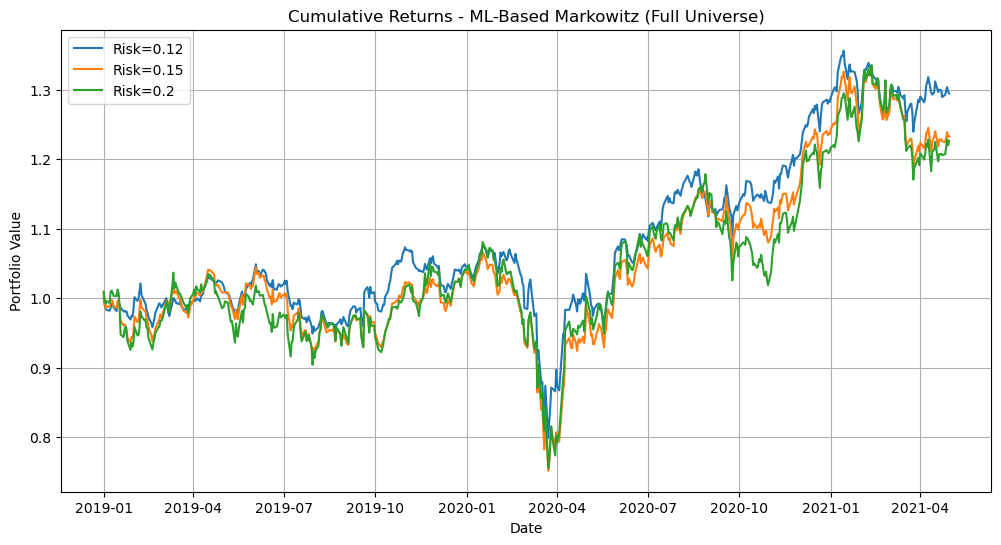

FULL UNIVERSE PERFORMANCE


,Risk Target,Annualized Return,Annualized Volatility,Sharpe Ratio
0,0.120000,13.15%,19.36%,0.679
1,0.150000,11.62%,22.20%,0.523
2,0.200000,11.99%,24.75%,0.484


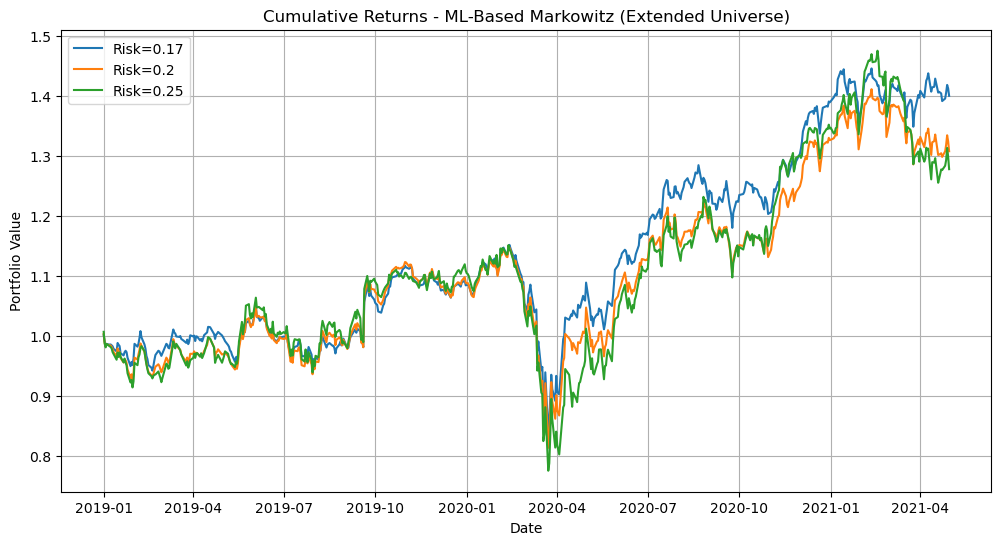

EXTENDED UNIVERSE PERFORMANCE


,Risk Target,Annualized Return,Annualized Volatility,Sharpe Ratio
0,0.170000,17.03%,21.56%,0.790
1,0.200000,14.55%,23.80%,0.612
2,0.250000,14.42%,27.20%,0.530


In [98]:
def evaluate_portfolios(portfolio_returns_dict, title_prefix):
    summary = []

    plt.figure(figsize=(12, 6))

    for rt, rets in portfolio_returns_dict.items():
        rets = rets.dropna()

        ann_return = rets.mean() * 252
        ann_vol = rets.std() * np.sqrt(252)
        sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

        summary.append({
            "Risk Target": rt,
            "Annualized Return": ann_return,
            "Annualized Volatility": ann_vol,
            "Sharpe Ratio": sharpe
        })

        cum_returns = (1 + rets).cumprod()
        plt.plot(cum_returns, label=f"Risk={rt}")

    plt.title(f"Cumulative Returns - {title_prefix}")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid(True)
    plt.show()

    return pd.DataFrame(summary)


# --- FULL UNIVERSE ---
summary_full = evaluate_portfolios(
    portfolio_returns_full,
    "ML-Based Markowitz (Full Universe)"
)

print("FULL UNIVERSE PERFORMANCE")
display(summary_full.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}"
}))


# --- EXTENDED UNIVERSE ---
summary_ext = evaluate_portfolios(
    portfolio_returns_ext,
    "ML-Based Markowitz (Extended Universe)"
)

print("EXTENDED UNIVERSE PERFORMANCE")
display(summary_ext.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}"
}))


### Comparison with standard Markowitz portfolio and simple baseline (equal-weight)

In [100]:
# --- CLASSIC MARKOWITZ (FULL & EXTENDED) ---

def classic_markowitz_weights(returns_train, cov_annual, risk_targets):
    weights = {}
    
    # Historical mean returns (daily → annualized)
    mu_classic = returns_train.mean() * 252
    
    for rt in risk_targets:
        mu_t = mu_classic.dropna()
        cov_t = cov_annual.loc[mu_t.index, mu_t.index]
        
        w, _ = solve_markowitz_variance_constrained(mu_t, cov_t, rt)
        weights[rt] = pd.Series(w, index=mu_t.index)
    
    return weights


# --- FULL UNIVERSE ---
classic_weights_full = classic_markowitz_weights(
    train_returns_full,
    cov_full_annual,
    risk_targets
)

# Realized returns
classic_returns_full = {}
for rt, w in classic_weights_full.items():
    assets = w.index.intersection(test_returns_full.columns)
    classic_returns_full[rt] = test_returns_full[assets] @ w[assets]


# --- EXTENDED UNIVERSE ---
classic_weights_ext = classic_markowitz_weights(
    train_returns_ext,
    cov_ext_annual,
    ext_risk_targets
)

classic_returns_ext = {}
for rt, w in classic_weights_ext.items():
    assets = w.index.intersection(test_returns_ext.columns)
    classic_returns_ext[rt] = test_returns_ext[assets] @ w[assets]

print("Classic Markowitz portfolios constructed (Full & Extended)")


Classic Markowitz portfolios constructed (Full & Extended)


In [102]:
# --- BASELINE 2: Equal-Weight (Full & Extended) ---

# Full universe
n_full = test_returns_full.shape[1]
w_eq_full = pd.Series(1 / n_full, index=test_returns_full.columns)
eq_returns_full = test_returns_full @ w_eq_full

# Extended universe
n_ext = test_returns_ext.shape[1]
w_eq_ext = pd.Series(1 / n_ext, index=test_returns_ext.columns)
eq_returns_ext = test_returns_ext @ w_eq_ext

### Comparison of ML Markowitz with Classical and Equal Weight

Across both asset universes, ML-based Markowitz portfolios deliver
competitive and in several cases superior risk-adjusted performance
relative to classical Markowitz and equal-weight benchmarks.

In the full universe, ML Markowitz achieves a Sharpe ratio of 0.679 at the
12% risk target, comparable to classical Markowitz (0.674) and above
equal-weight (0.619). At higher risk targets (15% and 20%), ML-based
portfolios outperform classical Markowitz in Sharpe terms and remain
competitive with equal-weight allocations.

In the extended universe, ML Markowitz performs particularly strongly,
achieving the highest Sharpe ratio of 0.790 at the 17% risk target,
exceeding both classical Markowitz (0.740) and equal-weight (0.571).
At higher risk levels, ML remains competitive and generally superior
to the classical approach in risk-adjusted terms.

Overall, the results indicate that ML-predicted expected returns provide
economically meaningful signal and improve portfolio efficiency,
particularly at moderate risk targets.

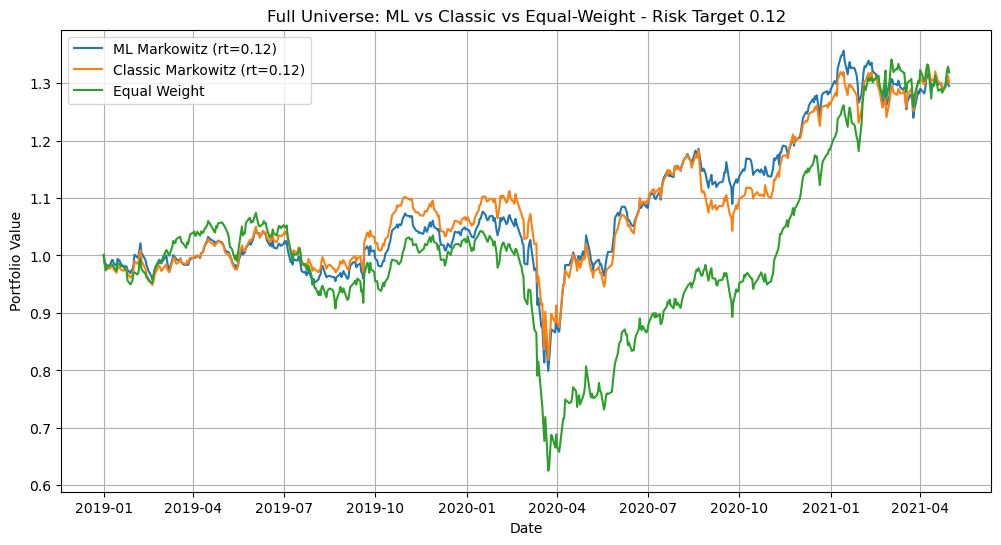

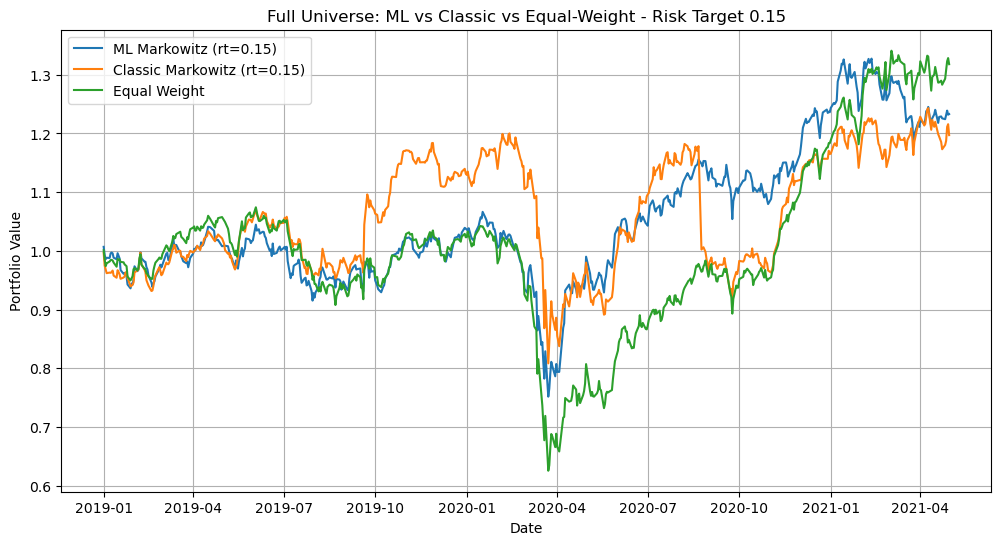

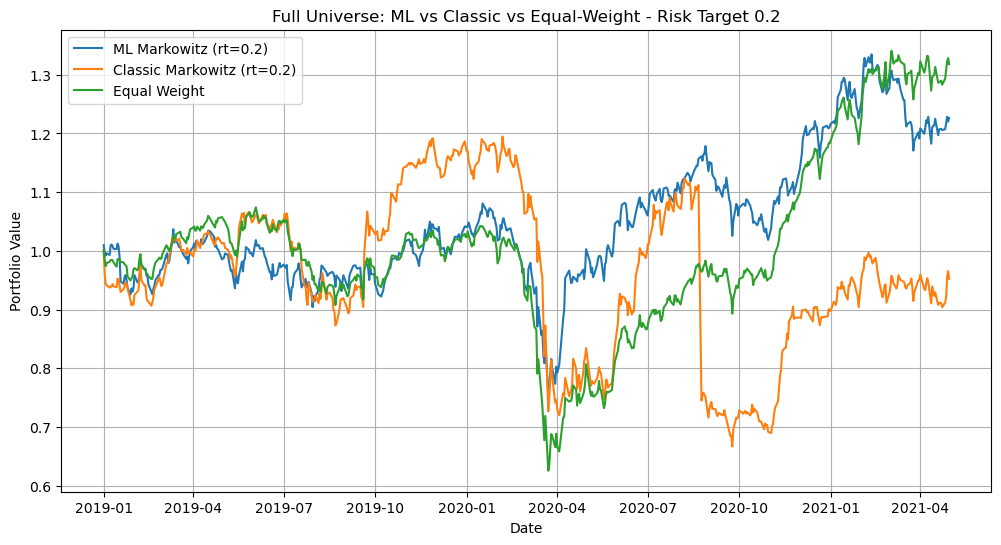

,Risk Target,Portfolio,Annualized Return,Annualized Volatility,Sharpe Ratio
0,0.120000,ML Markowitz (rt=0.12),13.15%,19.36%,0.679
1,0.120000,Classic Markowitz (rt=0.12),13.49%,20.02%,0.674
2,0.120000,Equal Weight,15.06%,24.33%,0.619
3,0.150000,ML Markowitz (rt=0.15),11.62%,22.20%,0.523
4,0.150000,Classic Markowitz (rt=0.15),11.41%,26.35%,0.433
5,0.150000,Equal Weight,15.06%,24.33%,0.619
6,0.200000,ML Markowitz (rt=0.2),11.99%,24.75%,0.484
7,0.200000,Classic Markowitz (rt=0.2),5.75%,37.73%,0.152
8,0.200000,Equal Weight,15.06%,24.33%,0.619


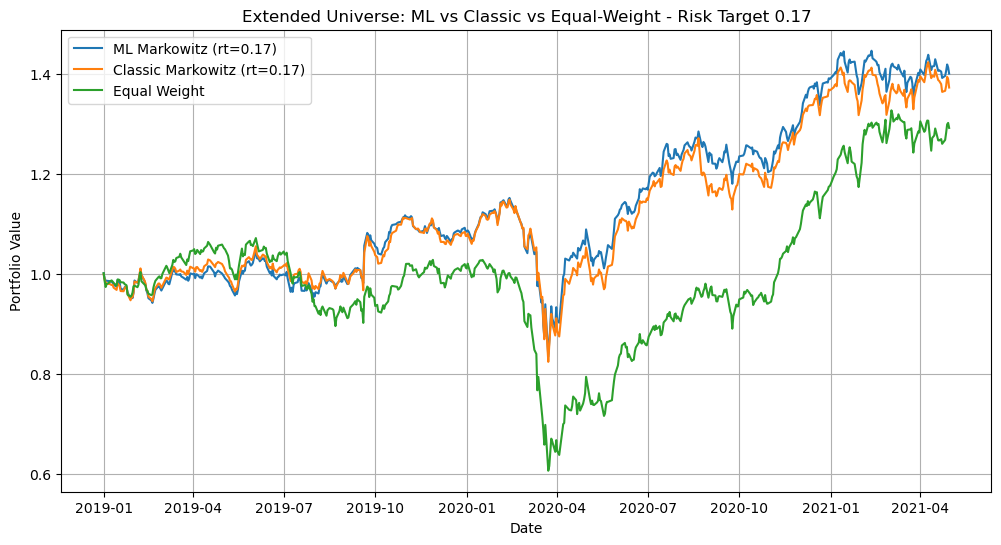

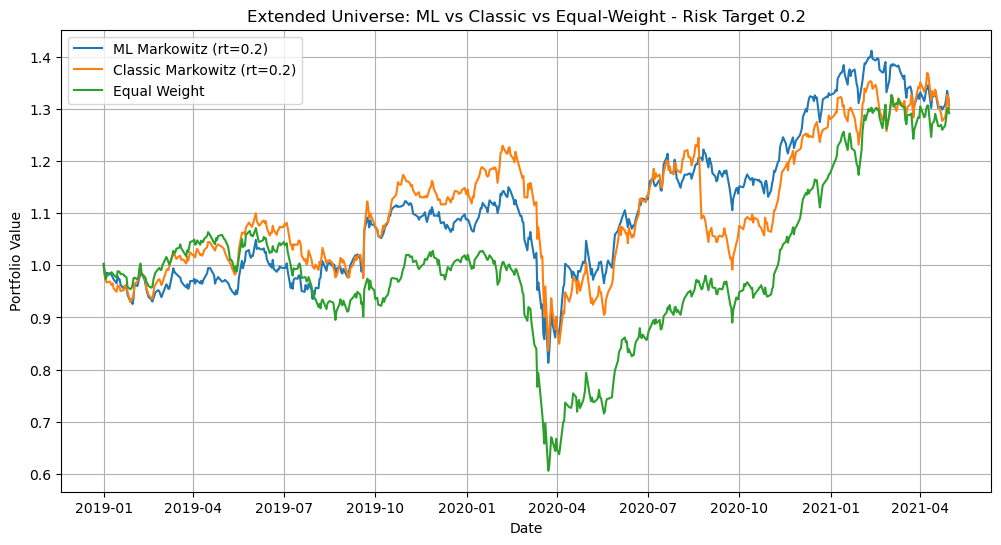

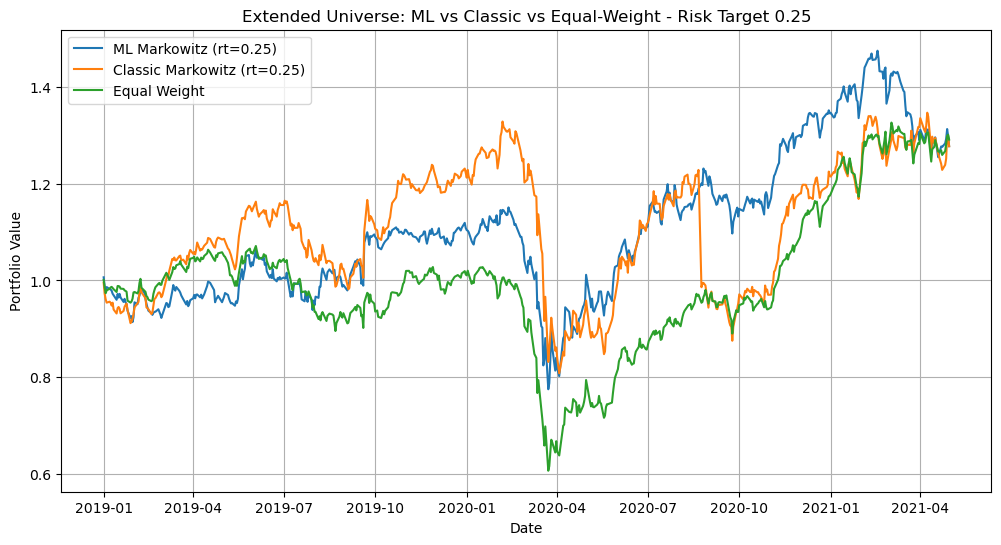

,Risk Target,Portfolio,Annualized Return,Annualized Volatility,Sharpe Ratio
0,0.170000,ML Markowitz (rt=0.17),17.03%,21.56%,0.790
1,0.170000,Classic Markowitz (rt=0.17),16.24%,21.94%,0.740
2,0.170000,Equal Weight,14.39%,25.22%,0.571
3,0.200000,ML Markowitz (rt=0.2),14.55%,23.80%,0.612
4,0.200000,Classic Markowitz (rt=0.2),14.99%,26.20%,0.572
5,0.200000,Equal Weight,14.39%,25.22%,0.571
6,0.250000,ML Markowitz (rt=0.25),14.42%,27.20%,0.530
7,0.250000,Classic Markowitz (rt=0.25),15.92%,31.74%,0.501
8,0.250000,Equal Weight,14.39%,25.22%,0.571


In [104]:
# --- MULTI-RISK COMPARISON FUNCTION ---

def compare_all_risk_levels(
    ml_returns_dict,
    classic_returns_dict,
    eq_returns,
    risk_targets,
    title_prefix
):
    all_summaries = []

    for rt in risk_targets:
        portfolios = {
            f"ML Markowitz (rt={rt})": ml_returns_dict[rt],
            f"Classic Markowitz (rt={rt})": classic_returns_dict[rt],
            "Equal Weight": eq_returns
        }

        summary = []
        plt.figure(figsize=(12, 6))

        for name, rets in portfolios.items():
            rets = rets.dropna()

            ann_ret = rets.mean() * 252
            ann_vol = rets.std() * np.sqrt(252)
            sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

            summary.append({
                "Risk Target": rt,
                "Portfolio": name,
                "Annualized Return": ann_ret,
                "Annualized Volatility": ann_vol,
                "Sharpe Ratio": sharpe
            })

            plt.plot((1 + rets).cumprod(), label=name)

        plt.title(f"{title_prefix} - Risk Target {rt}")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value")
        plt.legend()
        plt.grid(True)
        plt.show()

        all_summaries.extend(summary)

    return pd.DataFrame(all_summaries)


# =========================
# FULL UNIVERSE
# =========================

summary_full_all = compare_all_risk_levels(
    ml_returns_dict=portfolio_returns_full,
    classic_returns_dict=classic_returns_full,
    eq_returns=eq_returns_full,
    risk_targets=risk_targets,
    title_prefix="Full Universe: ML vs Classic vs Equal-Weight"
)

display(summary_full_all.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}"
}))


# =========================
# EXTENDED UNIVERSE
# =========================

summary_ext_all = compare_all_risk_levels(
    ml_returns_dict=portfolio_returns_ext,
    classic_returns_dict=classic_returns_ext,
    eq_returns=eq_returns_ext,
    risk_targets=ext_risk_targets,
    title_prefix="Extended Universe: ML vs Classic vs Equal-Weight"
)

display(summary_ext_all.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}"
}))


### Portfolio Holdings and Concentration Analysis (Full Universe)

To better understand performance differences, we examine portfolio holdings
and concentration across risk targets. Diversification is measured using the
effective number of assets:

$$
N_{\text{eff}} = \frac{1}{\sum_i w_i^2}
$$

which reflects the number of equally weighted assets to which the portfolio
is effectively equivalent. From the code, we display the top portfolio holdings (largest weights) for
each method and compute $N_{\text{eff}}$ using the full weight vector,
including all non-zero positions.

---

### Risk Target = 0.12

Both ML and Classic Markowitz portfolios remain moderately diversified.
ML exhibits slightly higher diversification (Effective N ≈ 14.9) compared
to Classic (≈ 13.4). Holdings overlap substantially, with allocations to
defensive and large-cap stocks. The equal-weight portfolio remains fully
diversified (Effective N = 50).

**Interpretation:**  
At low risk targets, both optimization approaches maintain broad exposure,
resulting in stable and comparable allocations.

---

### Risk Target = 0.15

Diversification declines meaningfully for both methods. Effective N falls
to ≈ 7.8 for ML and ≈ 7.5 for Classic Markowitz. Both optimizers begin
concentrating capital in a smaller set of high-expected-return assets,
though diversification levels remain similar across the two approaches.

**Interpretation:**  
Relaxing the risk constraint increases concentration, but neither method
dominates the other in diversification at this level.

---

### Risk Target = 0.20

At higher risk targets, portfolios become highly concentrated.
ML Markowitz has Effective N ≈ 4.3, while Classic Markowitz is slightly
more concentrated (≈ 4.1). Allocations are dominated by a small number of
stocks. Equal-weight remains fully diversified.

**Interpretation:**  
As risk tolerance increases, the optimizer amplifies differences in expected
returns, leading to concentrated positions in a handful of assets.

In [106]:
# -------------------------------
# Helper functions
# -------------------------------
def clean_weights(w, threshold=1e-5):
    w = w.copy()
    w[w.abs() < threshold] = 0.0
    return w[w != 0.0]

def summarize_weights(w, top_n=10):
    w = clean_weights(w)
    return w.sort_values(ascending=False).head(top_n)

def effective_n(w):
    return 1 / np.sum(w**2)

# -------------------------------
# DISPLAY ALL PORTFOLIOS
# -------------------------------
def display_all_portfolios(
    weights_ml,
    weights_classic,
    w_equal,
    risk_targets,
    universe_name
):
    print(f"\n==============================")
    print(f"{universe_name.upper()} UNIVERSE")
    print(f"==============================\n")

    for rt in risk_targets:
        print(f"\n--- Risk Target = {rt} ---\n")

        # ML Markowitz
        w_ml = weights_ml[rt]
        print("ML Markowitz - Top Holdings")
        display(summarize_weights(w_ml))
        print(f"Effective N (ML): {effective_n(w_ml):.2f}\n")

        # Classic Markowitz
        w_cl = weights_classic[rt]
        print("Classic Markowitz - Top Holdings")
        display(summarize_weights(w_cl))
        print(f"Effective N (Classic): {effective_n(w_cl):.2f}\n")

        # Equal-weight
        print("Equal-Weight Portfolio")
        print(f"Number of assets: {len(w_equal)}")
        print(f"Each weight: {w_equal.iloc[0]:.6f}")
        print(f"Effective N (Equal): {effective_n(w_equal):.2f}")
        print("-" * 40)


# ===============================
# FULL UNIVERSE
# ===============================
display_all_portfolios(
    weights_ml=weights_full,
    weights_classic=classic_weights_full,
    w_equal=w_eq_full,
    risk_targets=risk_targets,
    universe_name="Full"
)


FULL UNIVERSE


--- Risk Target = 0.12 ---

ML Markowitz - Top Holdings


Symbol
NESTLEIND     0.129201
COALINDIA     0.092189
DRREDDY       0.088780
HINDUNILVR    0.076757
CIPLA         0.070644
HEROMOTOCO    0.067915
TCS           0.064189
BHARTIARTL    0.053298
MARUTI        0.047762
WIPRO         0.047194
dtype: float64

Effective N (ML): 14.92

Classic Markowitz - Top Holdings


Symbol
NESTLEIND     0.127605
HINDUNILVR    0.123819
POWERGRID     0.110892
DRREDDY       0.073632
SHREECEM      0.067931
EICHERMOT     0.063426
BRITANNIA     0.062703
TCS           0.049908
BAJAJFINSV    0.045522
CIPLA         0.040102
dtype: float64

Effective N (Classic): 13.44

Equal-Weight Portfolio
Number of assets: 50
Each weight: 0.020000
Effective N (Equal): 50.00
----------------------------------------

--- Risk Target = 0.15 ---

ML Markowitz - Top Holdings


...

Effective N (Classic): 7.53

Equal-Weight Portfolio
Number of assets: 50
Each weight: 0.020000
Effective N (Equal): 50.00
----------------------------------------

--- Risk Target = 0.2 ---

ML Markowitz - Top Holdings


Symbol
SUNPHARMA     0.312242
HEROMOTOCO    0.226869
BHARTIARTL    0.224249
COALINDIA     0.164442
MARUTI        0.072199
dtype: float64

Effective N (ML): 4.32

Classic Markowitz - Top Holdings


Symbol
EICHERMOT     0.375724
BAJAJFINSV    0.259835
BRITANNIA     0.137390
BAJFINANCE    0.090933
SHREECEM      0.089171
HINDUNILVR    0.046946
dtype: float64

Effective N (Classic): 4.07

Equal-Weight Portfolio
Number of assets: 50
Each weight: 0.020000
Effective N (Equal): 50.00
----------------------------------------


### Portfolio Holdings and Concentration Analysis (Extended Universe)

We repeat the holdings and concentration analysis for the **extended universe**, which includes a smaller but longer-history set of assets.

In [108]:
# ===============================
# EXTENDED UNIVERSE
# ===============================
display_all_portfolios(
    weights_ml=weights_ext,
    weights_classic=classic_weights_ext,
    w_equal=w_eq_ext,
    risk_targets=ext_risk_targets,
    universe_name="Extended"
)



EXTENDED UNIVERSE


--- Risk Target = 0.17 ---

ML Markowitz - Top Holdings


Symbol
HEROMOTOCO    0.180378
HINDUNILVR    0.169851
BRITANNIA     0.093395
ASIANPAINT    0.085708
DRREDDY       0.074901
BHARTIARTL    0.073319
SHREECEM      0.056894
SUNPHARMA     0.053382
BPCL          0.051724
INFY          0.032468
dtype: float64

Effective N (ML): 9.92

Classic Markowitz - Top Holdings


Symbol
HINDUNILVR    0.134585
BRITANNIA     0.126652
SHREECEM      0.123336
HEROMOTOCO    0.109958
ASIANPAINT    0.104452
DRREDDY       0.083530
EICHERMOT     0.065358
BAJFINANCE    0.048982
SUNPHARMA     0.043894
HDFCBANK      0.026202
dtype: float64

Effective N (Classic): 11.02

Equal-Weight Portfolio
Number of assets: 38
Each weight: 0.026316
Effective N (Equal): 38.00
----------------------------------------

--- Risk Target = 0.2 ---

ML Markowitz - Top Holdings


...

Effective N (Classic): 7.45

Equal-Weight Portfolio
Number of assets: 38
Each weight: 0.026316
Effective N (Equal): 38.00
----------------------------------------

--- Risk Target = 0.25 ---

ML Markowitz - Top Holdings


Symbol
HEROMOTOCO    0.416535
KOTAKBANK     0.271702
BHARTIARTL    0.176550
BPCL          0.094399
HINDUNILVR    0.040813
dtype: float64

Effective N (ML): 3.46

Classic Markowitz - Top Holdings


Symbol
SHREECEM      0.369486
EICHERMOT     0.223870
BAJFINANCE    0.184029
TITAN         0.105976
ASIANPAINT    0.050391
BRITANNIA     0.041365
INDUSINDBK    0.024883
dtype: float64

Effective N (Classic): 4.23

Equal-Weight Portfolio
Number of assets: 38
Each weight: 0.026316
Effective N (Equal): 38.00
----------------------------------------


----

### 3. Pattern Discovery in the Same Dataset 

### Autocorrelation Analysis of Market Returns

To examine time-series structure independently of the machine learning model, we analyze the autocorrelation properties of daily market returns. The market return is constructed as the cross-sectional average of individual asset returns.

ACF and PACF plots are used to evaluate whether daily returns exhibit statistically significant linear dependence across short lags. This provides context for the inherent difficulty of forecasting financial returns.

The results indicate only a small positive autocorrelation at lag 1, which decays rapidly across higher lags. Most higher-order correlations are statistically insignificant, suggesting limited short-term time-series predictability at the daily frequency.

While the ML model predicts 15-day forward cumulative returns, the weak daily autocorrelation observed here highlights the noisy nature of return dynamics and helps explain why any predictive gains are expected to be modest.

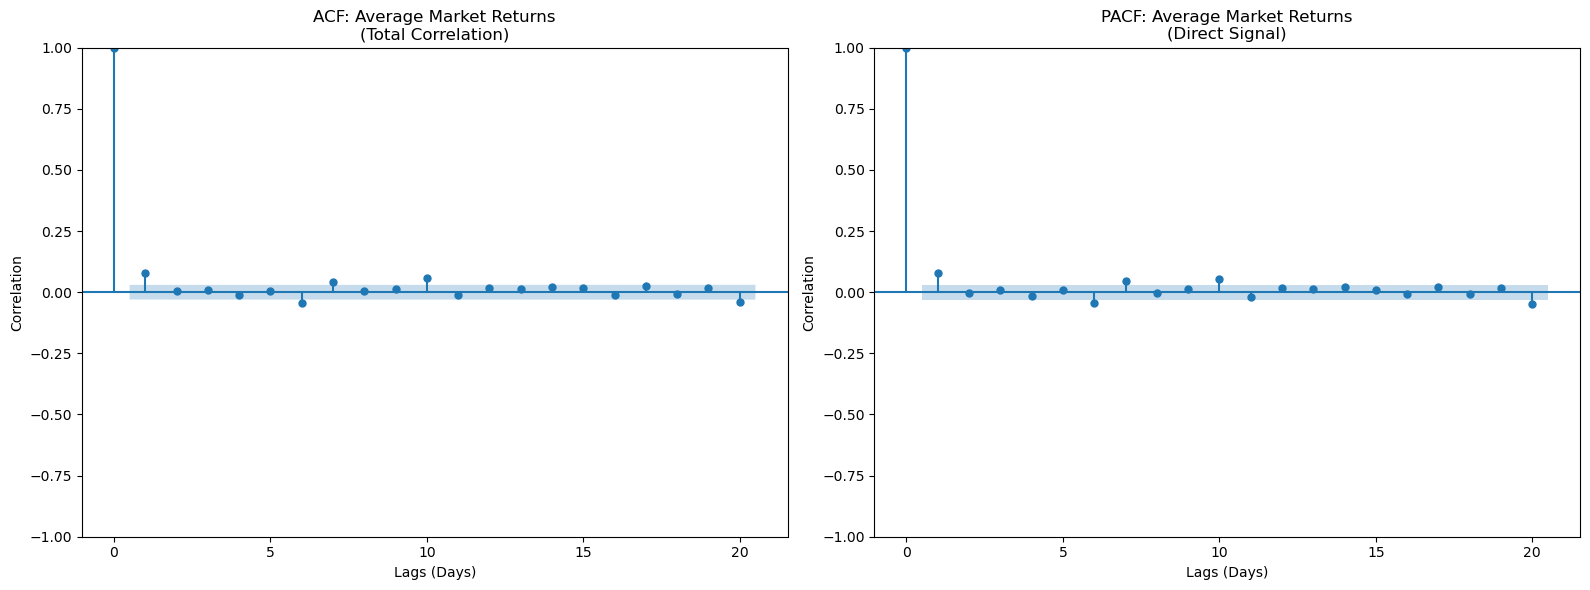

In [110]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Calculate the 'Market Factor' (Average return of all stocks)
# This washes out individual stock noise and shows the broad market pattern
avg_returns = returns_extended.mean(axis=1)

# 2. Create the plots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ACF (Autocorrelation Function)
# Shows the total correlation between today and a lag 'k' days ago
plot_acf(avg_returns.dropna(), lags=20, ax=ax[0], alpha=0.05)
ax[0].set_title("ACF: Average Market Returns\n(Total Correlation)")
ax[0].set_xlabel("Lags (Days)")
ax[0].set_ylabel("Correlation")

# PACF (Partial Autocorrelation Function)
# Shows ONLY the direct correlation of that specific lag, 
# stripping away the influence of the lags in between.
plot_pacf(avg_returns.dropna(), lags=20, ax=ax[1], alpha=0.05, method='ywm')
ax[1].set_title("PACF: Average Market Returns\n(Direct Signal)")
ax[1].set_xlabel("Lags (Days)")
ax[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

### Rolling Averages of Market Returns

Figure below plots daily market returns along with 20-day and 100-day rolling averages. Both rolling averages remain close to zero for most of the sample period, despite large day-to-day fluctuations in returns. Short-horizon averages display brief deviations from zero, but these signals reverse frequently and do not persist. The long-horizon average is even more stable and shows no sustained trend.

This indicates that daily market returns exhibit weak and unstable trends, making short-horizon return prediction difficult. As a result, models trained on daily return data are primarily exposed to noise rather than persistent signal.


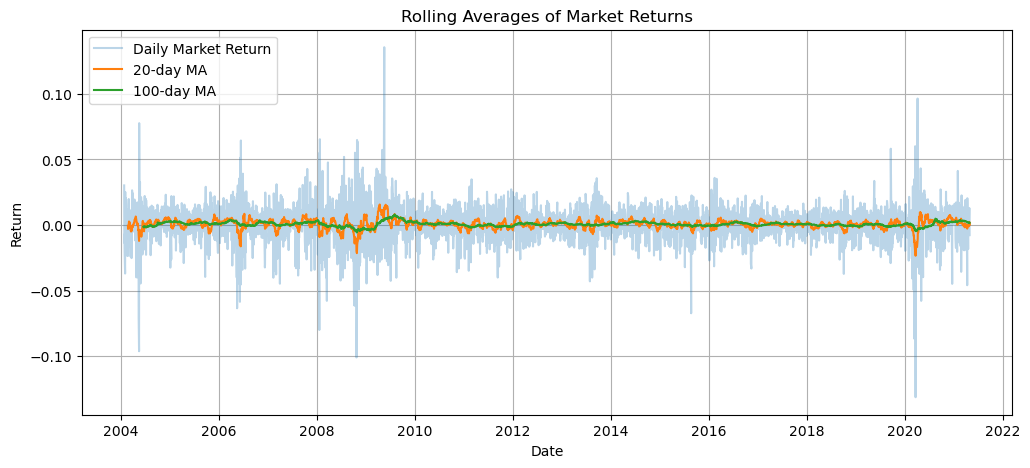

In [112]:
# --- ROLLING AVERAGES: MARKET RETURNS ---

market_returns = returns_extended.mean(axis=1)

short_window = 20   # ~1 month
long_window = 100   # ~5 months

roll_short = market_returns.rolling(short_window).mean()
roll_long = market_returns.rolling(long_window).mean()

plt.figure(figsize=(12, 5))
plt.plot(market_returns, alpha=0.3, label="Daily Market Return")
plt.plot(roll_short, label=f"{short_window}-day MA")
plt.plot(roll_long, label=f"{long_window}-day MA")
plt.title("Rolling Averages of Market Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()


### Rolling Volatility and Risk Regimes

Figure below shows the 30-day rolling annualized volatility of market returns. Unlike rolling averages of returns, volatility exhibits clear persistence and clustering. Periods of elevated volatility tend to follow one another, while calm periods persist for extended durations.

Several distinct high-volatility regimes are visible, corresponding to market stress episodes, whereas prolonged low-volatility regimes characterize calmer market conditions. This indicates that while return levels are difficult to predict, risk dynamics display more stable and learnable structure.

These findings suggest that volatility—and broader risk regimes—are more predictable than returns themselves, which helps explain why models that attempt to forecast returns perform poorly, while risk-based or regime-aware approaches may be more effective.


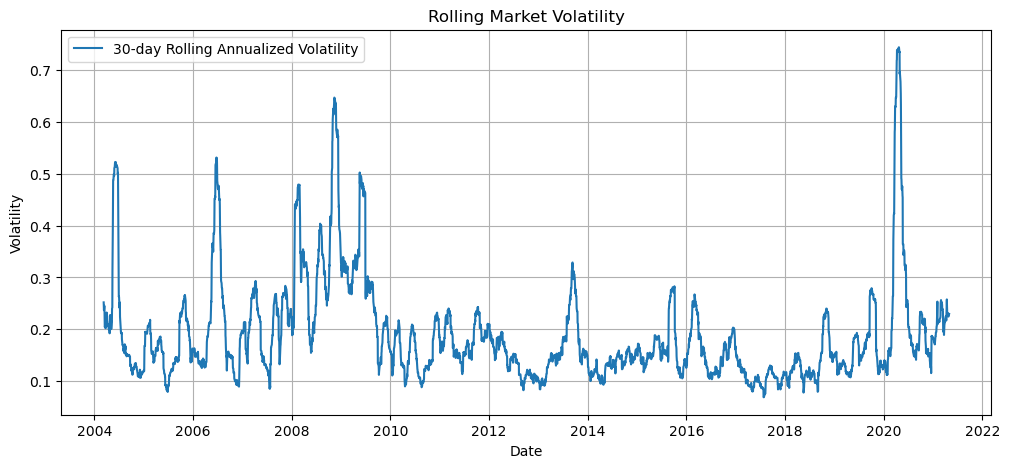

In [114]:
# Rolling volatility of market returns (extended universe)

market_returns = returns_extended.mean(axis=1)

vol_window = 30  # ~1.5 months
rolling_vol = market_returns.rolling(vol_window).std() * np.sqrt(252)

plt.figure(figsize=(12, 5))
plt.plot(rolling_vol, label="30-day Rolling Annualized Volatility")
plt.title("Rolling Market Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()


### Drawdowns and Recovery Dynamics

Figure below illustrates the market drawdown, defined as the percentage decline from the previous cumulative return peak. The plot shows that drawdowns are episodic but severe, with large losses occurring during well-known market stress periods, most notably around the global financial crisis in 2008 and the COVID-19 market shock in 2020.

These stress episodes are characterized by rapid drawdowns followed by prolonged recovery phases, indicating that losses accumulate quickly while recoveries occur more gradually. The timing of these drawdowns aligns closely with the elevated volatility regimes observed earlier, reinforcing the persistence of market stress once it emerges.

This behavior underscores the importance of diversification and robustness in portfolio construction. During extended drawdown periods such as 2008 and 2020, concentrated portfolios are particularly vulnerable, whereas broadly diversified portfolios are better positioned to withstand sustained market stress.


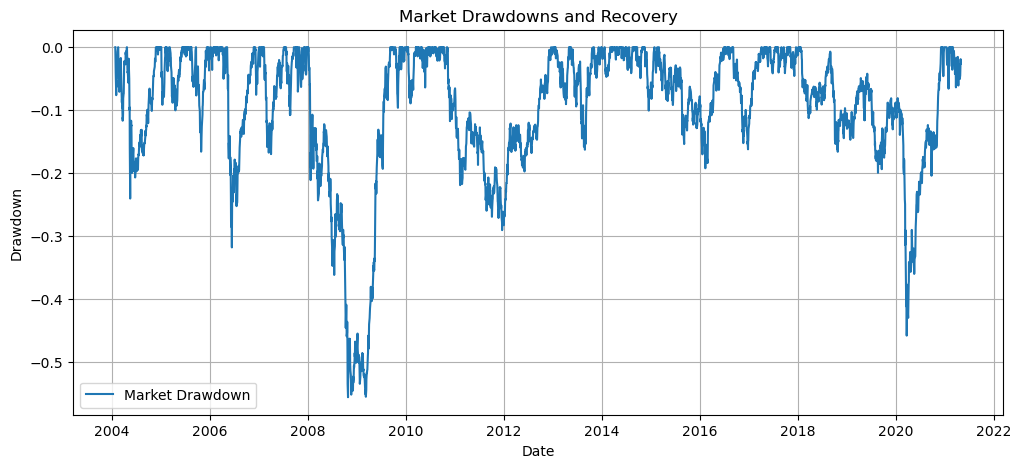

In [116]:
# --- DRAWDOWN ANALYSIS ---

# Market cumulative returns
market_returns = returns_extended.mean(axis=1)
cum_market = (1 + market_returns).cumprod()

# Running maximum
running_max = cum_market.cummax()

# Drawdown
drawdown = (cum_market - running_max) / running_max

plt.figure(figsize=(12, 5))
plt.plot(drawdown, label="Market Drawdown")
plt.title("Market Drawdowns and Recovery")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()


### Regime Shifts: Calm vs Stressed Periods

Figure below explicitly identifies market regimes based on rolling volatility. Periods in which the 30-day rolling annualized volatility exceeds a threshold (75th percentile of historical volatility) are classified as **stressed regimes**, while periods below the threshold are classified as **calm regimes**.

The stressed regimes align closely with known market stress episodes, most notably during the global financial crisis around 2008–2009 and the COVID-19 shock in 2020. These periods are characterized by elevated and persistent volatility, whereas calm regimes exhibit lower and more stable volatility over extended durations.

This clear separation highlights the presence of regime shifts in market risk dynamics. While return levels show little persistent structure, volatility exhibits regime-dependent behavior that is both observable and persistent. This suggests that market risk is state-dependent, with stress regimes lasting long enough to materially affect portfolio performance and robustness.


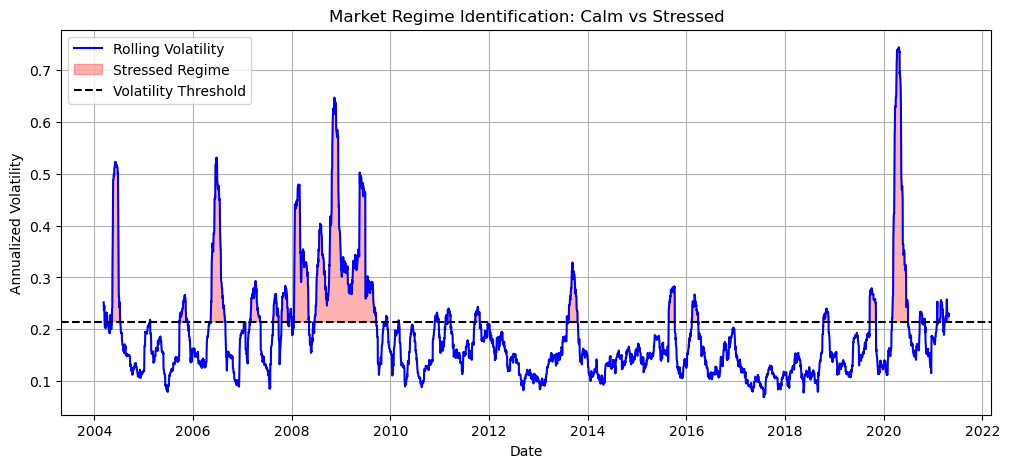

Volatility threshold used: 0.21458468855729043


In [118]:
# --- REGIME SHIFT IDENTIFICATION (CALM VS STRESSED) ---

market_returns = returns_extended.mean(axis=1)

# Rolling volatility (reuse)
vol_window = 30
rolling_vol = market_returns.rolling(vol_window).std() * np.sqrt(252)

# Define regime threshold (e.g. 75th percentile of volatility)
vol_threshold = rolling_vol.quantile(0.75)

# Regime labels
regime = pd.Series(
    np.where(rolling_vol > vol_threshold, "Stressed", "Calm"),
    index=rolling_vol.index
)

# Plot volatility with regimes highlighted
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol, label="Rolling Volatility", color="blue")

plt.fill_between(
    rolling_vol.index,
    rolling_vol,
    vol_threshold,
    where=(rolling_vol > vol_threshold),
    color="red",
    alpha=0.3,
    label="Stressed Regime"
)

plt.axhline(vol_threshold, color="black", linestyle="--", label="Volatility Threshold")

plt.title("Market Regime Identification: Calm vs Stressed")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

print("Volatility threshold used:", vol_threshold)


### Summary of Time-Series Pattern Discovery

Analysis of rolling averages, volatility, drawdowns, and regime shifts reveals a clear asymmetry in the structure of market returns. Rolling averages of daily returns remain close to zero across both short and long horizons, indicating that deviations in the conditional mean are weak, short-lived, and difficult to exploit. This suggests limited predictability of return levels at the daily frequency.

In contrast, rolling volatility exhibits strong persistence and clustering, with extended calm periods punctuated by distinct high-volatility regimes. Explicit regime classification based on volatility highlights clear stress periods, most notably during the global financial crisis of 2008–2009 and the COVID-19 shock in 2020. These stressed regimes persist over time and are associated with elevated risk.

Drawdown analysis further illustrates the economic consequences of these regimes. Market stress episodes are characterized by rapid and deep drawdowns followed by prolonged recovery periods, reinforcing the importance of robustness and diversification in portfolio construction. Together, these findings indicate that while return predictability is weak, risk dynamics exhibit meaningful and persistent structure.


----

### 4. Critical Reflection: Where ML Helps vs Hurts

This analysis evaluates the use of machine learning to estimate 15-day forward cumulative returns and integrate those estimates into static mean–variance portfolio optimization.

### Where Machine Learning Helped

Machine learning delivered competitive and, in several cases, superior risk-adjusted performance relative to the classical Markowitz benchmark. In both asset universes, ML-based portfolios achieved comparable or higher Sharpe ratios at moderate risk targets, with particularly strong results in the extended universe.

These gains appear to stem from improved cross-sectional ranking of assets rather than strong time-series predictability. By forecasting 15-day cumulative returns, the model reduces short-term noise and produces smoother expected return estimates. This allows the optimizer to allocate capital more efficiently toward higher-ranked assets within imposed risk constraints.

### Where Machine Learning Hurt

Despite improved performance, ML-based portfolios remain sensitive to estimation error. As risk targets increase, portfolio concentration rises sharply, with the effective number of assets declining meaningfully. This highlights a structural feature of mean–variance optimization: small differences in expected return estimates are magnified into large allocation shifts.

Additionally, while ML often outperformed the classical benchmark, equal-weight portfolios remained competitive. This underscores the continued importance of diversification and suggests that ML signals, while economically meaningful, are not overwhelmingly strong.

### Performance, Robustness, and Interpretation

Overall, ML improved portfolio efficiency without evident instability or extreme overfitting. The results are economically plausible and consistent with weak-form efficiency: return predictability exists, but is modest in magnitude and primarily cross-sectional.

The findings suggest that ML can enhance expected return estimation within a disciplined optimization framework, though diversification remains a dominant driver of long-run performance.

### Future Scope

Future work could explore dynamic rebalancing with rolling ML forecasts, alternative forecast horizons, or applying machine learning to volatility modeling and regime detection. Incorporating shrinkage, regularization, or stronger portfolio constraints may further improve robustness when translating ML signals into optimized allocations.